# b · Des variantes du modèle calibré

Le modèle calibré est une estimation : certaines choses y restent inconnues. Une variante en tire
une valeur plausible au hasard. Avec plusieurs variantes, on voit ce que cette incertitude fait
aux capteurs, et on peut fabriquer des scénarios de fuite sur un réseau qui n'est pas exactement
le modèle.

Le code est dans `generation/variantes.py`. Quatre familles :

| famille | ce qui est tiré |
|---|---|
| `conduites` | longueur, diamètre et rugosité de chaque conduite (±3 % par défaut) |
| `composition` | la part résidentiel / commercial des nœuds sans compteur, volume total inchangé |
| `decalage` | chaque nœud sans compteur consomme jusqu'à 30 min plus tôt ou plus tard |
| `bruit` | la consommation d'un nœud fluctue autour de sa forme, à chaque pas de 5 min |

Les nœuds équipés d'un compteur, la pompe et le niveau du réservoir ne bougent jamais : ils sont
mesurés.

Les deux réglages qui comptent, la plage des conduites et la taille du bruit, sont mesurés aux
sections 4 et 5 plutôt que choisis.

In [1]:
import sys; sys.path.insert(0, "..")
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from generation import modele as M, scenarios as S, variantes as V, figures as F
from calibration import ameliorations as A

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

## Réglages

In [2]:
ANNEE = 2018
DEBUT_JOUR, N_JOURS = 0, 3         # trois jours suffisent à voir les effets
N_VARIANTES = 8                    # par famille
FAMILLES = V.FAMILLES
PLAGES = dict(V.PLAGES)            # conduites ±3 %, composition ±20 %
CV_BRUIT = V.CV_BRUIT              # 0,40
DOSSIER = M.SORTIES / "variantes"

# Sections 4 et 5 : les périodes de contrôle, hors de la fenêtre où les rugosités ont été ajustées
PERIODES = (91, 182, 274)          # début avril, juillet, octobre
PLAGES_TESTEES = (0.02, 0.05, 0.10, 0.20)
CV_TESTES = (0.20, 0.30, 0.40, 0.478)

# La fuite de comparaison (section 8)
CONDUITE, DEBIT = "p232", 10.0

## 1. Le modèle de référence

In [3]:
fen = M.fenetre(ANNEE, DEBUT_JOUR, N_JOURS)
ref = M.simuler(fen)
print("modèle calibré - mesure :",
      {k: round(v, 3) for k, v in M.erreur(ref[:, fen.colonnes], fen.p_mes).items()})

modèle calibré - mesure : {'biais_m': 0.003, 'dispersion_m': 0.062, 'rmse_m': 0.062}


## 2. Une variante

Ce qui a été tiré pour la variante 0.

réseau modifié écrit dans : sorties/variantes/variante_0000.inp
composition : {'Residential': 0.99, 'Commercial': 0.992, 'Industrial': 1.0}


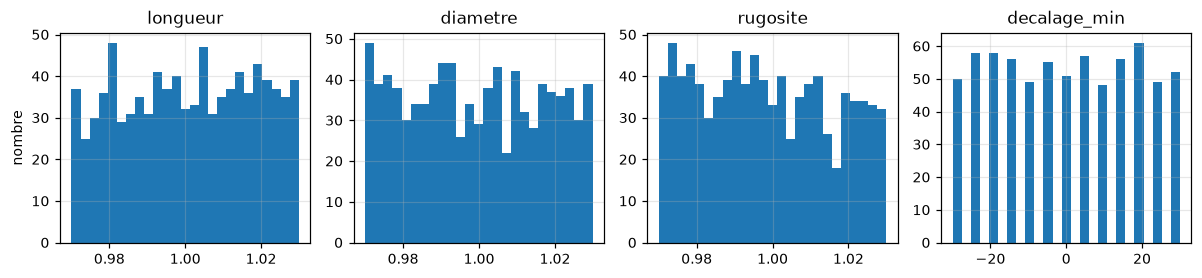

In [4]:
v = V.tirer(fen, graine=0, familles=FAMILLES, plages=PLAGES, dossier=DOSSIER, cv_bruit=CV_BRUIT)
print("réseau modifié écrit dans :", v.inp.relative_to(M.DOSSIER))
print("composition :", {k: round(float(x), 3) for k, x in v.tirages["composition"].items()})

fig, ax = plt.subplots(1, 4, figsize=(11, 2.6))
for a, nom in zip(ax, ["longueur", "diametre", "rugosite", "decalage_min"]):
    a.hist(v.tirages[nom], bins=25, color="tab:blue")
    a.set_title(nom)
ax[0].set_ylabel("nombre")
fig.tight_layout()

La demande d'un nœud sans compteur, le premier jour, avant et après.

volume total de la variante / modèle calibré : 1.0029


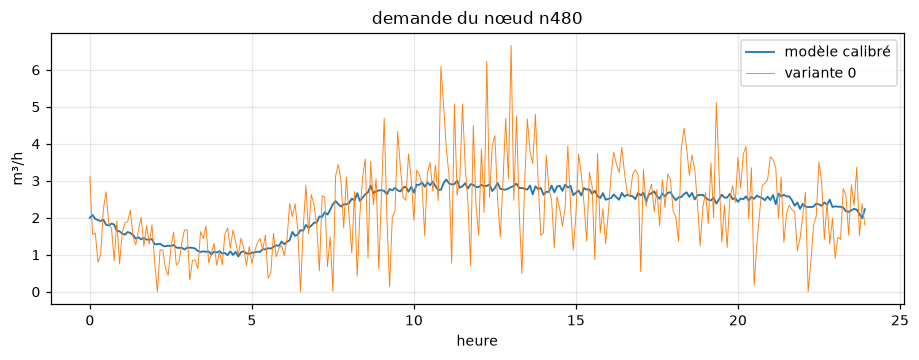

In [5]:
libres = np.flatnonzero(~fen.mesure)
k = libres[fen.bases[libres].sum(axis=1).argmax()]         # le plus gros nœud sans compteur
jour = slice(0, M.PAS_JOUR)

fig, ax = plt.subplots()
ax.plot(fen.jours[jour] * 24, fen.D[jour, k], lw=1.2, label="modèle calibré")
ax.plot(fen.jours[jour] * 24, v.D[jour, k], lw=0.6, label="variante 0")
ax.set(xlabel="heure", ylabel="m³/h", title=f"demande du nœud {fen.noeuds[k]}"); ax.legend()

print(f"volume total de la variante / modèle calibré : {v.D.sum() / fen.D.sum():.4f}")

## 3. Famille par famille

`N_VARIANTES` tirages pour chaque famille seule, puis pour toutes ensemble. On regarde l'écart
aux capteurs par rapport au modèle calibré, séparé en deux :

- **statique** : un décalage constant par capteur ;
- **dynamique** : ce qui bouge autour de ce décalage, dans le temps.

In [6]:
sims = {}
for famille in FAMILLES + ("toutes",):
    familles = FAMILLES if famille == "toutes" else (famille,)
    sims[famille] = [M.simuler(fen, **V.tirer(fen, g, familles, PLAGES, DOSSIER, CV_BRUIT).kw)
                     for g in range(N_VARIANTES)]

effets = pd.DataFrame({f: V.ecarts(fen, ref, s) for f, s in sims.items()}).T * 100
effets.columns = ["statique (cm)", "dynamique (cm)"]
effets.round(2)

,statique (cm),dynamique (cm)
conduites,1.25,0.61
composition,0.27,0.54
decalage,0.08,1.89
bruit,0.24,5.59
toutes,1.29,6.00


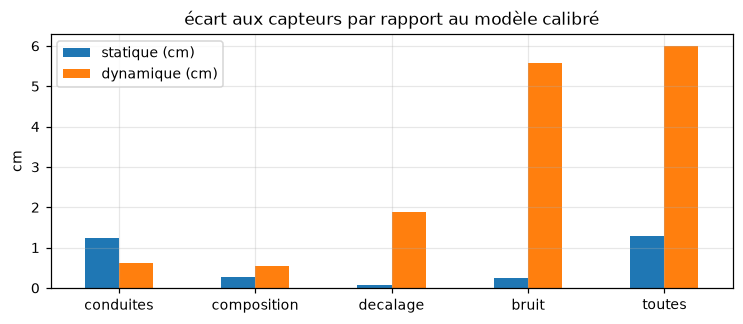

In [7]:
ax = effets.plot.bar(figsize=(8, 3), rot=0)
ax.set(ylabel="cm", title="écart aux capteurs par rapport au modèle calibré");

Les conduites ne décalent plus les capteurs que d'un peu plus d'un centimètre. La partie
dynamique vient presque toute du bruit, comme dans la vraie mesure. Pourquoi ±3 % et ce bruit-là :
sections 4 et 5.

## 4. Régler la plage des conduites

Une variante de conduites doit s'écarter du modèle calibré autant que le vrai réseau s'en écarte,
pas plus. On mesure donc le décalage du modèle aux capteurs sur trois périodes où il n'a pas été
ajusté.

Ces périodes contiennent les vraies fuites de 2018, qui décalent aussi les capteurs. Pour ne
garder que l'erreur du modèle, on y pose les fuites publiées, chacune à sa conduite.

In [8]:
def decalage_statique(e):
    '''Le décalage moyen de chaque capteur dans le temps, en moyenne quadratique sur les 33 (cm).'''
    return float(np.sqrt(np.nanmean(np.nanmean(e, axis=0) ** 2)) * 100)

lignes, fenetres = [], {}
for jour in PERIODES:
    f = M.fenetre(ANNEE, jour, N_JOURS)
    fenetres[jour] = f
    lisse = M.simuler(f)
    D_fuites = A.poser_fuites_publiees(f.D, f.noeuds, f.wn, ANNEE, debut=f.debut)
    avec_fuites = M.simuler(f, D=D_fuites)
    ligne = {"période": str(f.horo[0].date()),
             "modèle, sans fuite": decalage_statique(lisse[:, f.colonnes] - f.p_mes),
             "modèle, fuites posées": decalage_statique(avec_fuites[:, f.colonnes] - f.p_mes)}
    for plage in PLAGES_TESTEES:
        p = {**PLAGES, "longueur": plage, "diametre": plage, "rugosite": plage}
        s = [M.simuler(f, **V.tirer(f, g, ("conduites",), p, DOSSIER).kw) for g in range(4)]
        ligne[f"variantes ±{plage:.0%}"] = V.ecarts(f, lisse, s)["statique_m"] * 100
    lignes.append(ligne)
reglage_conduites = pd.DataFrame(lignes).set_index("période")
reglage_conduites.round(2)

,"modèle, sans fuite","modèle, fuites posées",variantes ±2%,variantes ±5%,variantes ±10%,variantes ±20%
période,,,,,,
2018-04-02,8.34,1.5,1.07,3.03,7.94,27.22
2018-07-02,8.97,1.9,1.36,3.83,10.04,34.38
2018-10-02,13.89,1.9,1.26,3.57,9.32,31.88


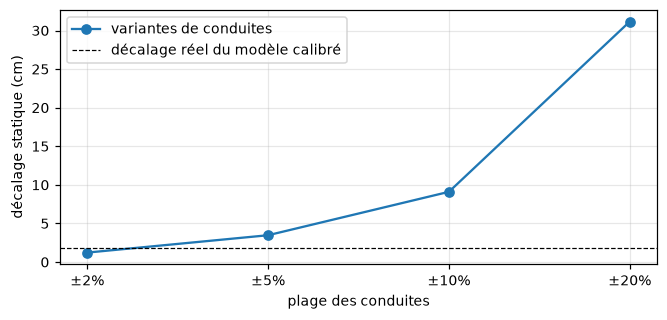

In [9]:
moyenne = reglage_conduites.mean()
fig, ax = plt.subplots(figsize=(7, 3))
x = range(len(PLAGES_TESTEES))
ax.plot(x, moyenne[[f"variantes ±{p:.0%}" for p in PLAGES_TESTEES]], marker="o",
        label="variantes de conduites")
ax.axhline(moyenne["modèle, fuites posées"], color="k", ls="--", lw=0.8,
           label="décalage réel du modèle calibré")
ax.set(xticks=list(x), xticklabels=[f"±{p:.0%}" for p in PLAGES_TESTEES],
       xlabel="plage des conduites", ylabel="décalage statique (cm)")
ax.legend();

Une fois les fuites posées, le modèle calibré n'est décalé que de 1,5 à 1,9 cm hors de sa fenêtre
d'ajustement. Les 8 à 14 cm du modèle sans fuite, c'étaient les vraies fuites de 2018.

±2 % donne 1,1 à 1,4 cm, ±5 % déjà 3 à 3,8 cm : la bonne plage est autour de ±3 %. Les ±20 % de
la documentation valent pour le modèle nominal, avant calibration ; ici, ils écarteraient les
capteurs de 27 à 34 cm.

## 5. Régler la taille du bruit

Le bruit de consommation fait sautiller la pression d'un pas de 5 min à l'autre. Sa taille se
règle en comparant ce sautillement à celui des vrais capteurs : écart-type du saut d'un pas au
suivant, médiane sur les 33 capteurs.

In [10]:
def saut(p):
    '''Écart-type du saut d'un pas de 5 min au suivant, médiane sur les capteurs (cm).'''
    return float(np.median(np.nanstd(np.diff(p, axis=0), axis=0)) * 100)

lignes = []
for jour, f in {DEBUT_JOUR: fen, **fenetres}.items():
    ligne = {"période": str(f.horo[0].date()), "mesure": saut(f.p_mes),
             "modèle lisse": saut(M.simuler(f)[:, f.colonnes])}
    for cv in CV_TESTES:
        v_bruit = V.tirer(f, 0, ("bruit",), cv_bruit=cv)
        ligne[f"bruit CV {cv}"] = saut(M.simuler(f, **v_bruit.kw)[:, f.colonnes])
    lignes.append(ligne)
reglage_bruit = pd.DataFrame(lignes).set_index("période")
reglage_bruit.round(2)

,mesure,modèle lisse,bruit CV 0.2,bruit CV 0.3,bruit CV 0.4,bruit CV 0.478
période,,,,,,
2018-01-01,8.36,3.56,5.14,6.75,8.50,9.85
2018-04-02,10.82,4.13,6.32,8.38,10.61,12.33
2018-07-02,13.69,5.05,7.87,10.52,13.35,15.54
2018-10-02,12.82,4.73,7.54,10.01,12.64,14.68


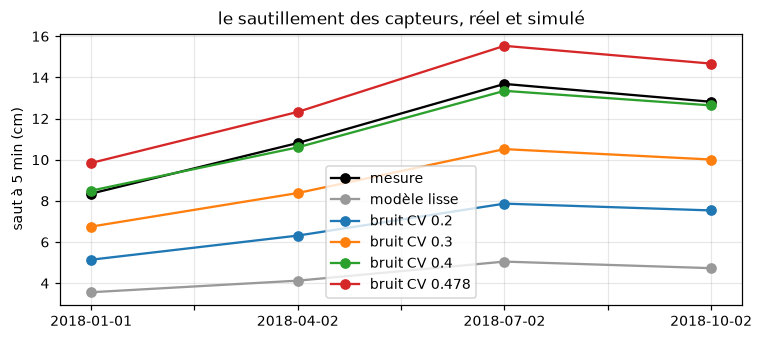

In [11]:
ax = reglage_bruit.plot(marker="o", figsize=(8, 3.2), color=["k", "0.6"] + [f"C{i}" for i in range(len(CV_TESTES))])
ax.set(ylabel="saut à 5 min (cm)", xlabel="", title="le sautillement des capteurs, réel et simulé");

Le modèle lisse sautille deux à trois fois moins que la mesure. Un CV de 0,40 retrouve le
sautillement réel aux quatre saisons, à 0,4 cm près. Le 0,478 mesuré sur les compteurs en fait 13
à 18 % de trop.

Ce réglage suppose que les capteurs n'ajoutent presque pas de bruit eux-mêmes. S'ils en
ajoutaient, le bon CV serait encore un peu plus petit.

## 6. Toutes les familles ensemble

Au capteur où les variantes s'écartent le plus.

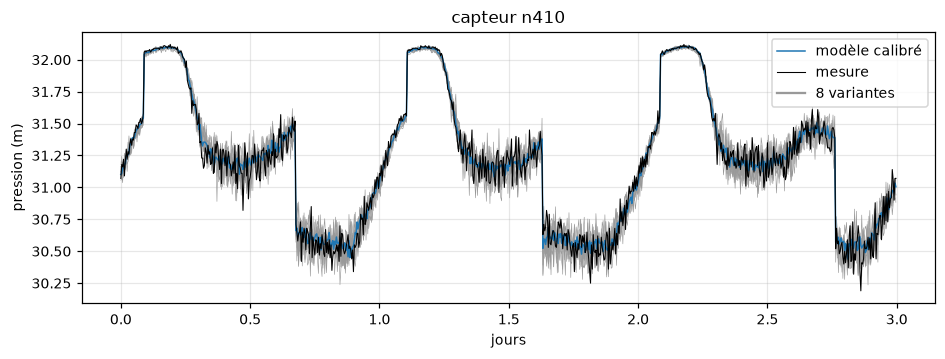

In [12]:
toutes = np.stack([s[:, fen.colonnes] for s in sims["toutes"]])     # (variantes, pas, 33)
c = int(toutes.std(axis=0).mean(axis=0).argmax())

fig, ax = plt.subplots()
for s in toutes:
    ax.plot(fen.jours, s[:, c], color="0.6", lw=0.4)
ax.plot(fen.jours, ref[:, fen.colonnes[c]], lw=1.0, label="modèle calibré")
ax.plot(fen.jours, fen.p_mes[:, c], color="k", lw=0.7, label="mesure")
ax.plot([], [], color="0.6", label=f"{N_VARIANTES} variantes")
ax.set(xlabel="jours", ylabel="pression (m)", title=f"capteur {fen.capteurs[c]}"); ax.legend();

Les variantes entourent la mesure au lieu de passer à côté.

Où l'incertitude se trouve dans le réseau : l'écart-type, entre variantes, de la pression moyenne
de chaque jonction.

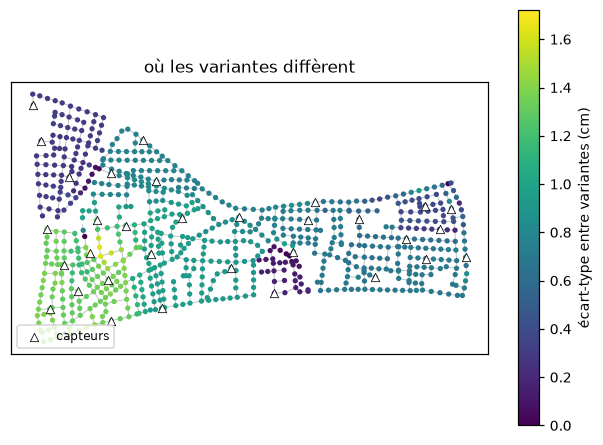

In [13]:
moyennes = np.stack([s.mean(axis=0) for s in sims["toutes"]])        # (variantes, 782)
ax = F.carte(fen.wn, valeurs=dict(zip(fen.noeuds, moyennes.std(axis=0) * 100)), cmap="viridis",
             unite="écart-type entre variantes (cm)", titre="où les variantes diffèrent")
F.reperer(ax, fen.wn, fen.capteurs, couleur="white", marque="^", taille=30, etiquette="capteurs")

## 7. La mesure tombe-t-elle dans l'enveloppe ?

Pour chaque capteur, la part du temps où la mesure est entre la plus basse et la plus haute des
variantes.

en moyenne sur les 33 capteurs : 68%


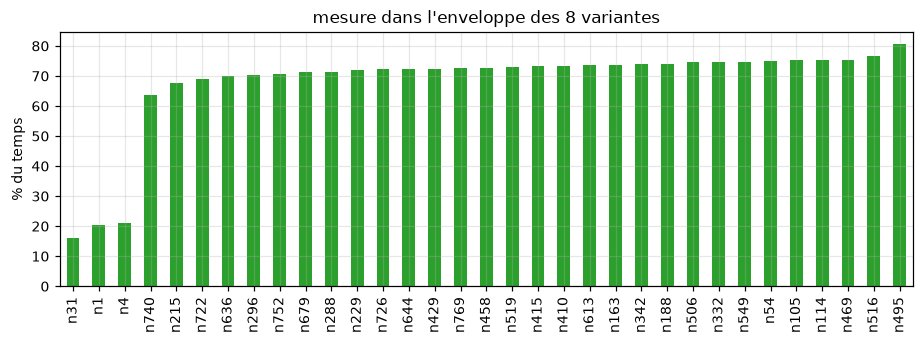

In [14]:
bas, haut = toutes.min(axis=0), toutes.max(axis=0)
dedans = pd.Series(((fen.p_mes >= bas) & (fen.p_mes <= haut)).mean(axis=0), index=fen.capteurs)

ax = (dedans * 100).sort_values().plot.bar(figsize=(10, 3), color="tab:green")
ax.set(ylabel="% du temps", title=f"mesure dans l'enveloppe des {N_VARIANTES} variantes")
print(f"en moyenne sur les 33 capteurs : {dedans.mean():.0%}")

68 % du temps. Avec les ±20 % et le CV de 0,478, c'était 39 % : l'enveloppe était plus large, mais
décalée vers le bas.

## 8. Et une fuite, à côté ?

Une fuite de 10 m³/h pendant 48 h, comparée à l'écart des variantes au capteur qui la voit le
mieux.

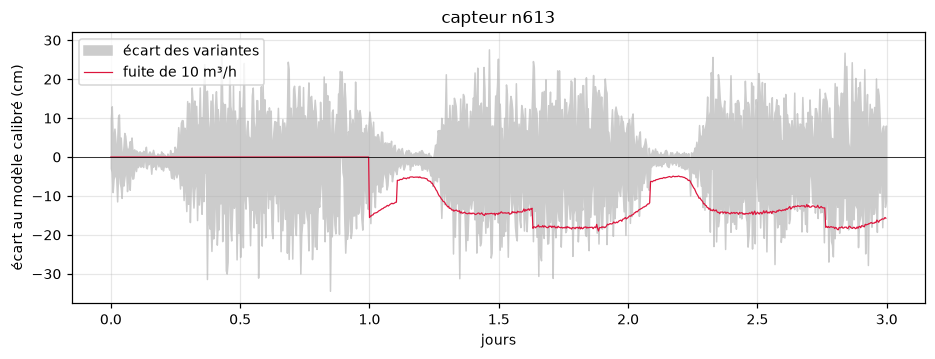

In [15]:
fuite = S.Fuite(CONDUITE, debut_h=24, duree_h=48, debit_m3h=DEBIT)
p, _ = S.simuler_fuites(fen, [fuite], ref)
signal = (ref - p)[:, fen.colonnes] * 100
cf = int(signal.mean(axis=0).argmax())

ecart = (toutes[:, :, cf] - ref[:, fen.colonnes[cf]]) * 100
fig, ax = plt.subplots()
ax.fill_between(fen.jours, ecart.min(axis=0), ecart.max(axis=0), color="0.8",
                label="écart des variantes")
ax.plot(fen.jours, -signal[:, cf], color="crimson", lw=0.8, label=f"fuite de {DEBIT:.0f} m³/h")
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="jours", ylabel="écart au modèle calibré (cm)", title=f"capteur {fen.capteurs[cf]}")
ax.legend();

Le bruit fait des pointes de ±20 cm d'un pas à l'autre, mais il ne dure pas. La fuite décale la
pression de 15 cm pendant deux jours. Le bruit étant blanc, une moyenne sur une heure (12 pas) le
divise déjà par √12 ≈ 3,5.

## 9. Des scénarios de fuite sur des variantes

`simuler_fuites` et `generer_lot` acceptent une variante : il suffit de passer `**v.kw`. Trois
variantes, trois scénarios chacune.

In [16]:
rng = np.random.default_rng(0)
lots = []
for g in range(3):
    v = V.tirer(fen, g, FAMILLES, PLAGES, DOSSIER, CV_BRUIT)
    scenarios = [S.tirer_fuites(fen, rng, duree_h=(24, 48)) for _ in range(3)]
    dossier = M.SORTIES / "lot_variantes" / f"variante_{g:04d}"
    index = S.generer_lot(fen, scenarios, dossier, **v.kw)
    (dossier / "variante.json").write_text(json.dumps(
        {"graine": g, "familles": list(FAMILLES), "plages": PLAGES, "cv_bruit": CV_BRUIT}, indent=2))
    lots.append(index.assign(variante=g))
pd.concat(lots, ignore_index=True)

,scenario,n_fuites,conduites,volume_m3,variante
0,temoin,0,,0.0,0
1,scenario_001,1,p463,32.9,0
2,scenario_002,1,p159,220.9,0
3,scenario_003,1,p879,212.0,0
4,temoin,0,,0.0,1
5,scenario_001,1,p251,36.9,1
6,scenario_002,1,p502,633.9,1
7,scenario_003,1,p81,70.3,1
8,temoin,0,,0.0,2
9,scenario_001,1,p436,45.2,2


## À retenir

- Deux réglages mesurés, pas choisis : conduites ±3 %, bruit CV 0,40.
- Les ±20 % de la documentation décrivent l'incertitude du modèle nominal. Autour du modèle
  calibré, ils écartent les capteurs de 30 cm, deux fois une fuite de 10 m³/h.
- Le modèle calibré est lisse exprès : c'est la meilleure estimation. Le bruit n'y est ajouté que
  pour que les variantes ressemblent à une vraie mesure.
- Une variante se passe partout avec `**v.kw` : simulation, fuites, lots.